# NICER Data: Compute Power Density Spectrum (PDS) for MAXI J1535–571

This notebook demonstrates the pipeline for generating the PDS from a cleaned `.evt` file using NICER observations, based on the methodology from the paper you provided.

# Step 1: Load the event file (FITS format) and filter energies


In [2]:
from astropy.io import fits
import numpy as np

evt_file = "cleaned_file_2.evt"
with fits.open(evt_file) as hdul:
    data = hdul[1].data
    times = data['TIME']
    pis = data['PI']
    hdr = hdul[0].header  # primary header; you can also check hdul[1].header if needed
    obs_id = hdr.get('OBS_ID', 'Not found') 
print("Observation ID:", obs_id)

# Filter for 2–6 keV range (PI ~ 200–600)
mask = (pis >= 200) & (pis <= 600)
filtered_times = times[mask]

Observation ID: 1130360109


# Step 2: Create a light curve (binning at 2⁻¹³ s)

<Axes: xlabel='Time (s)', ylabel='counts'>

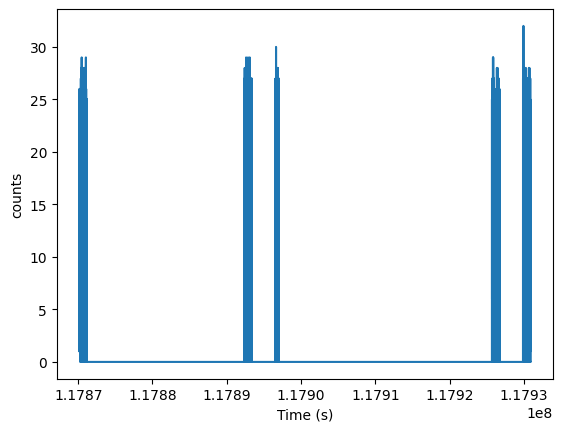

In [4]:
# Step 3: Create a light curve (binning at 2⁻¹³ s)
from stingray import Lightcurve

dt = 1/1000 
t_start = filtered_times.min()
t_end = filtered_times.max()
bins = np.arange(t_start, t_end, dt)
counts, _ = np.histogram(filtered_times, bins=bins)

lc = Lightcurve(time=bins[:-1], counts=counts, dt=dt)
lc.plot()

# Step 3: Compute averaged power spectrum

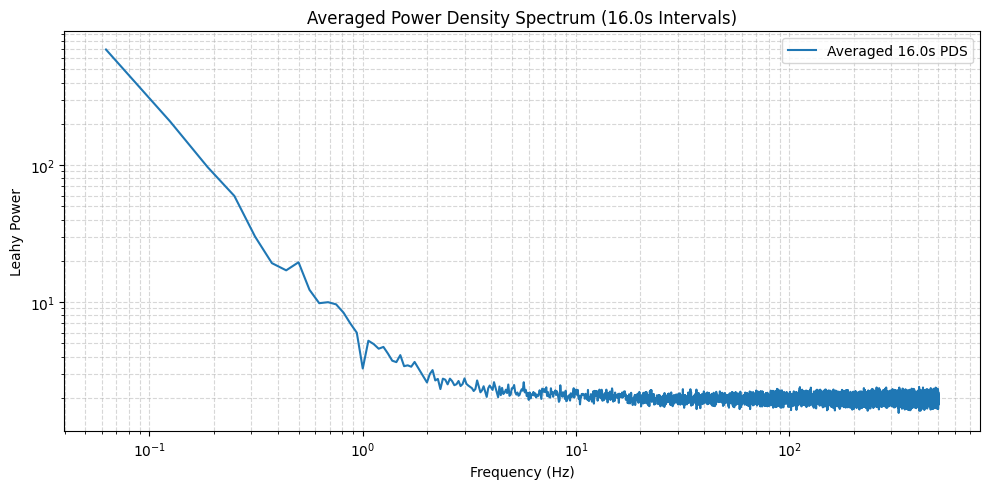

In [5]:
from stingray import AveragedPowerspectrum
import matplotlib.pyplot as plt
# Segment size in seconds (e.g., 16s if GTI > 160s)
segment_size = 16.0
aps = AveragedPowerspectrum(lc, segment_size=segment_size, norm='leahy')
plt.figure(figsize=(10, 5))
plt.loglog(aps.freq, aps.power, label=f'Averaged {segment_size}s PDS')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Leahy Power")
plt.title(f"Averaged Power Density Spectrum ({segment_size}s Intervals)")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
freq = aps.freq
power = aps.power

## Step 4: Fit Lorentzian to PDS
Here, we fit a Lorentzian model to the power density spectrum to identify QPO features.


Trial 1
f₀ = 4.000, γ = 3.470, K = 0.200, Q = 1.15
Reduced χ² = 0.0199

Trial 2
f₀ = 5.101, γ = 0.109, K = 0.358, Q = 47.01
Reduced χ² = 0.0217
Q > 2, significant Lorentzian detected.

Trial 3
f₀ = 5.677, γ = 0.059, K = 0.500, Q = 96.63
Reduced χ² = 0.0211

Trial 4
f₀ = 5.677, γ = 0.059, K = 0.500, Q = 96.64
Reduced χ² = 0.0211

Trial 5
f₀ = 5.931, γ = 0.075, K = 0.000, Q = 78.92
Reduced χ² = 0.0234


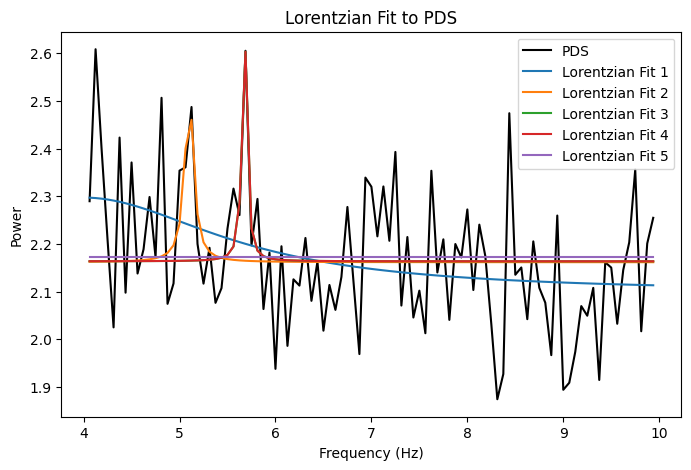

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Lorentzian function with constant background ---
def lorentzian_with_background(f, f0, gamma, K, C):
    return K * (0.5 * gamma)**2 / ((f - f0)**2 + (0.5 * gamma)**2) + C

# --- Load / Simulate PDS data ---
# Replace with real PDS data from your source
# Simulated structure (you already have something like this)
freq = aps.freq
power = aps.power

# Filter PDS to reasonable region
mask = (freq > 4) & (freq < 10)
freq_fit = freq[mask]
power_fit = power[mask]

# --- Initial guesses for f0 ---
initial_guesses_f0 = [4.5, 5.0, 5.5, 6.0, 6.5]
gamma_guess = 0.5
lower_bounds = [4.0, 0.05, 0.0, 0.0]   # e.g. gamma > 0.05 to avoid sharp spikes
upper_bounds = [10, 5.0, 100.0, 10.0]
K_guess = np.max(power_fit)
C_guess = np.min(power_fit)

fit_success = False
obs_id = 'Obs_id001'
results = []
plt.figure(figsize=(8, 5))
plt.plot(freq_fit, power_fit, label="PDS", color="black")

for i, f0 in enumerate(initial_guesses_f0):
    try:
        p0 = [f0, gamma_guess, K_guess, C_guess]
        popt, pcov = curve_fit(lorentzian_with_background, freq_fit, power_fit, p0=p0, bounds=(lower_bounds, upper_bounds))
        # print(popt)
        f0_fit, gamma_fit, K_fit, C_fit = popt
        Q = f0_fit / gamma_fit
        model_fit = lorentzian_with_background(freq_fit, *popt)

        # Reduced Chi²
        residuals = power_fit - model_fit
        chi2 = np.sum(residuals**2)
        red_chi2 = chi2 / (len(freq_fit) - len(popt))

        print(f"\nTrial {i+1}")
        print(f"f₀ = {f0_fit:.3f}, γ = {gamma_fit:.3f}, K = {K_fit:.3f}, Q = {Q:.2f}")
        print(f"Reduced χ² = {red_chi2:.4f}")
        
        if K_fit>0:
            plt.plot(freq_fit, model_fit, label=f'Lorentzian Fit {i+1}')

        # Significance check
        if Q > 2 and Q<50:
            print("Q > 2, significant Lorentzian detected.")
            fit_success = True
            results.append([obs_id, f0_fit, gamma_fit, K_fit])

    except RuntimeError:
        print(f" Fit failed at guess f₀ = {f0}")
        continue

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Lorentzian Fit to PDS")
plt.legend()
plt.show()

# Adding the detected QPO to a csv file
